 #                         🧠 CNN vs FFNN: Architecture Comparison & Benchmarking.

##  ================ 📖 Project Introduction.  ==================

Deep learning models have become one of the most powerful approaches in modern artificial intelligence due to their ability to automatically learn complex patterns from data. Among the most widely used neural network architectures are Feedforward Neural Networks (FFNNs) and Convolutional Neural Networks (CNNs). Although both belong to the same family of neural networks, each architecture is designed differently and performs differently depending on the nature of the dataset and the learning task.

This project focuses on building, training, optimizing, and evaluating both architectures using the same dataset in order to perform a fair and detailed comparison between them. The project aims to analyze how each model behaves during training, how well it generalizes to unseen data, and how architectural design impacts overall performance.

Throughout this project, several important stages of the deep learning pipeline are covered, including:

Exploratory Data Analysis (EDA)
Data preprocessing
Neural network design
Model training and optimization
Performance evaluation
Benchmarking and comparison

The comparison between CNN and FFNN is not limited to prediction accuracy only, but also includes:

Training efficiency
Inference speed
Overfitting and underfitting behavior
Regularization effects
Learning stability across epochs

By the end of the project, a complete evaluation is performed to identify the strengths and limitations of each architecture and determine which model is more suitable for the selected dataset and task

##  ================🎯 Project Objectives ====================

The main objectives of this project are:

To understand the fundamental differences between FFNN and CNN architectures.
To perform proper data preprocessing and preparation before model training.
To explore the dataset using visual and statistical analysis techniques.
To implement both neural network models from scratch using deep learning frameworks.
To optimize model performance using suitable training and regularization techniques.
To compare both models using multiple evaluation metrics and benchmarking methods.
To analyze training behavior, model generalization, and computational efficiency.
To gain practical experience in designing and evaluating deep learning systems

## 📚 Importing Required Libraries

This cell imports all the libraries and modules needed throughout the project. Each library plays an important role in building, training, evaluating, and visualizing the neural network models

####  🔹 `import torch`
Used for deep learning and tensor operations.

####  🔹 `import torch.nn as nn`
Provides neural network layers and model components.

####  🔹 `import torch.optim as optim`
Imports optimization algorithms like Adam and SGD.


####  🔹 `from torchvision import datasets, transforms`
Used for loading image datasets and preprocessing.

####  🔹 `from torch.utils.data import DataLoader, random_split`
Tools for batching, shuffling, and splitting datasets.

####  🔹 `from sklearn.metrics import accuracy_score, f1_score`
Metrics used to evaluate model performance.

#### 🔹 `from sklearn.metrics import classification_report`
Generates a detailed classification report.

#### 🔹 `from collections import Counter`
Counts element frequencies in datasets.

####  🔹 `from sklearn.metrics import confusion_matrix`
Creates a confusion matrix for prediction analysis.

#### 🔹 `import seaborn as sns`
Visualization library used for heatmaps and statistical plots.

####  🔹 `import matplotlib.pyplot as plt`
Used for plotting graphs and visualizations.

#### 🔹 `import pandas as pd`
Library for data handling and table creation.

#### 🔹 `import numpy as np`
Used for numerical and array operations.

#### 🔹 `import random`
Provides randomization functions.

#### 🔹 `import time`
Used for measuring execution time.

#### 🔹 `from tqdm import tqdm`
Displays progress bars during loops and training.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from tqdm import tqdm

# 🧪 Data Transformation & Augmentation Pipeline

This section defines the preprocessing and augmentation pipeline applied to the images before feeding them into the neural network models. The goal is to standardize the input data and improve model generalization, especially for the CNN and FFNN architectures.

Two transformation pipelines are created:
- A **basic transformation pipeline** for validation/test data


## 🔹 `transform` (Basic Preprocessing Pipeline)

This transformation is applied to validation and test datasets to ensure consistent and stable evaluation.

### 📌 Steps:

#### 🔸 `transforms.Resize((128, 128))`
Resizes all input images to a fixed size of **128×128 pixels**.

- Ensures uniform input dimensions
- Required for batch processing in neural networks
- Helps both FFNN and CNN accept consistent input shapes


#### 🔸 `transforms.ToTensor()`
Converts images into PyTorch tensors.

- Changes image format from PIL/numpy to tensor
- Scales pixel values to range [0, 1]
- Enables GPU processing and backpropagation


#### 🔸 `transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])`
Normalizes pixel values for each RGB channel.

- Centers data around 0
- Stabilizes and speeds up training
- Improves convergence of gradient descent


## 🔹 `train_transform` (Data Augmentation Pipeline)

This transformation is applied only to the training dataset to artificially increase data diversity and improve model generalization.


### 📌 Steps:

#### 🔸 `transforms.Resize((128, 128))`
Ensures all training images have a consistent size of 128×128 pixels.


#### 🔸 `transforms.RandomHorizontalFlip()`
Randomly flips images horizontally with a probability of 50%.

- Simulates different viewing angles
- Helps reduce overfitting
- Improves model robustness


#### 🔸 `transforms.RandomRotation(10, fill=[255, 255, 255])`
Randomly rotates images within a range of ±10 degrees.

- Introduces slight variations in orientation
- Helps the model generalize better
- `fill=[255,255,255]` fills empty areas with white pixels after rotation

#### 🔸 `transforms.ToTensor()`
Converts images into tensors and scales pixel values.

#### 🔸 `transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])`
Normalizes the image data to improve training stability and convergence.


## 💡 Why This Step Is Important

This preprocessing and augmentation stage is critical because:

- Ensures consistent input size for both CNN and FFNN
- Improves training stability through normalization
- Reduces overfitting using data augmentation
- Increases model robustness to real-world variations



In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10,fill=[255,255,255]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [3]:

full_dataset = datasets.ImageFolder(
    root=r"C:\Users\MSBCD\Downloads\dataset-original",
    transform=transform
)
full_dataset_train = datasets.ImageFolder(
    root=r"C:\Users\MSBCD\Downloads\dataset-original",
    transform=train_transform
)


# 🗂️ Dataset Overview and Basic Inspection

This cell prints important information about the dataset such as its size, number of classes, label mapping, and image dimensions. It is used to verify that the dataset is correctly loaded before training.

---

## 🔹 Dataset inspection functions

These lines are used to explore the dataset structure.

### 📌 What it does:
- `len(full_dataset)` → counts total number of images
- `full_dataset.classes` → shows all class names
- `full_dataset.class_to_idx` → maps class names to numeric labels
- `full_dataset[0][0].shape` → shows shape of one image tensor

---

## 🔹 Important parameters / variables

### 📌 `full_dataset`
- The complete dataset object (usually created using `ImageFolder`)
- Contains all images and their corresponding labels

### 📌 Important notes:
- Dataset path determines number of samples and classes
- Folder names define class names automatically
- Image transformations affect final image shape (resize, normalization, etc.)

---

## 🔹 Output Explanation

### 📌 Output:
- **Total samples: 2527**  
  → There are 2527 images in the dataset

- **Number of classes: 6**  
  → The dataset contains 6 categories

- **Class to Index:**  
  `{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}`  
  → Each class is converted into a numeric label for training the model

- **Image shape: torch.Size([3, 128, 128])**  
  → Each image is RGB (3 channels) with resolution 128×128 pixels

### 📌 Why it is important:
- Confirms dataset is loaded correctly
- Ensures label encoding is consistent
- Verifies image dimensions match CNN input requirements

### 📌 How to interpret:
- 2527 samples → dataset size available for training/testing
- 6 classes → classification problem with 6 outputs
- `[3, 128, 128]` → suitable format for convolutional neural networks

In [4]:
print("Total samples:", len(full_dataset))
print("Number of classes:", len(full_dataset.classes))
print("Class to Index:", full_dataset.class_to_idx)
print("Image shape:", full_dataset[0][0].shape)

Total samples: 2527
Number of classes: 6
Class to Index: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Image shape: torch.Size([3, 128, 128])


# 🗂️ Class Distribution in the Dataset

This cell calculates and displays how many images exist in each class. It helps you understand whether the dataset is balanced or imbalanced before training the model.

---

## 🔹 `np.bincount(full_dataset.targets)`

This function is used to count occurrences of each class label.

### 📌 What it does:
- `full_dataset.targets` → list of numeric labels for all images
- `np.bincount()` → counts how many times each class index appears
- Returns an array where each index corresponds to a class

---

## 🔹 Important variables

### 📌 `full_dataset.targets`
- Contains the label (class index) of every image in the dataset
- Example: `[0, 1, 1, 2, 0, ...]`

### 📌 Important notes:
- Changing dataset will change these counts automatically
- Class imbalance can affect model performance
- Works only if labels are numeric (as in ImageFolder)

---

## 🔹 Output Explanation

### 📌 Output:
- **cardboard : 403**
- **glass : 501**
- **metal : 410**
- **paper : 594**
- **plastic : 482**
- **trash : 137**

### 📌 What it shows:
- Number of images in each class of the dataset

### 📌 Why it is important:
- Shows dataset balance across categories
- Helps detect class imbalance (e.g., `trash` is much smaller)
- Important for deciding training strategies (like class weights or augmentation)

### 📌 How to interpret:
- Largest class: **paper (594 images)** → most represented
- Smallest class: **trash (137 images)** → underrepresented
- This imbalance may cause the model to be biased toward majority classes

In [5]:
class_counts = np.bincount(full_dataset.targets)

print("\nClass Counts:")
for cls_name, count in zip(full_dataset.classes, class_counts):
    print(f"{cls_name} : {count}")


Class Counts:
cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137


# 🗂️ Class Distribution Visualization (Bar Plot)

This cell visualizes the number of images in each class using a bar chart. It helps to clearly see whether the dataset is balanced or imbalanced.

---

## 🔹 `np.bincount(full_dataset.targets)`

This function counts how many samples belong to each class.

### 📌 What it does:
- Reads all class labels from `full_dataset.targets`
- Counts occurrences of each class index
- Returns an array like: `[403, 501, 410, ...]`

---

## 🔹 `matplotlib.pyplot.bar()`

This function creates a bar chart to visualize class distribution.

### 📌 What it does:
- Takes class names on the x-axis
- Takes class counts on the y-axis
- Draws a bar for each class

---

## 🔹 Important parameters / variables

### 📌 `full_dataset.classes`
- List of class names (e.g., cardboard, glass, etc.)
- Used as labels on the x-axis

### 📌 `class_counts`
- Number of images in each class
- Must match order of `full_dataset.classes`

### 📌 Important notes:
- If dataset changes → plot automatically updates
- Rotation (`rotation=45`) improves readability of class names
- `tight_layout()` prevents label overlap

---

## 🔹 Output Explanation

### 📌 What the plot shows:
- A bar for each class in the dataset
- Height of each bar = number of images in that class

### 📌 Why it is important:
- Makes class imbalance very easy to see visually
- Helps decide if you need:
  - data augmentation
  - class weighting
  - resampling

### 📌 How to interpret:
- Taller bars → more samples in that class
- Short bars → underrepresented classes
- In this dataset:
  - **paper** is the largest class
  - **trash** is the smallest class
  - This indicates an imbalanced dataset

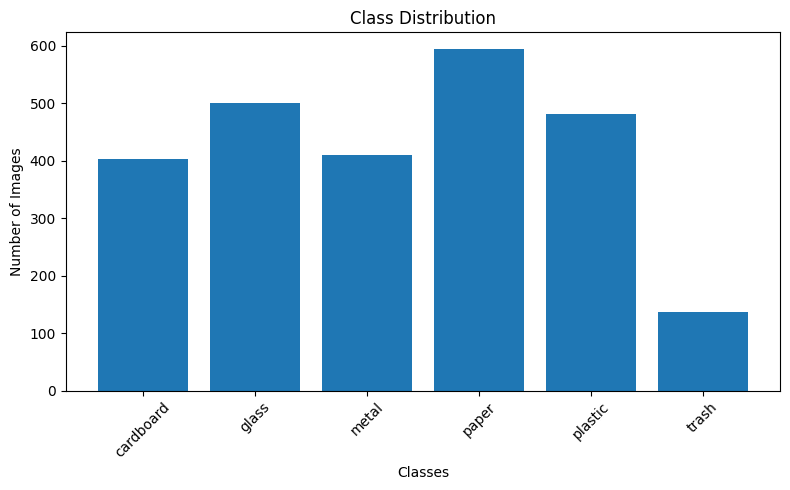

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class_counts = np.bincount(full_dataset.targets)

plt.figure(figsize=(8,5))

plt.bar(
    full_dataset.classes,
    class_counts
)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 🗂️ Detecting Class Imbalance in the Dataset

This cell finds the largest and smallest classes in the dataset and checks whether the dataset is balanced or imbalanced. It helps decide if special handling is needed during training.

---

## 🔹 `np.bincount(full_dataset.targets)`

This function counts how many samples exist in each class.

### 📌 What it does:
- Reads all labels from `full_dataset.targets`
- Counts frequency of each class index
- Returns an array of class counts

---

## 🔹 `np.argmax()` and `np.argmin()`

These functions find the most and least frequent classes.

### 📌 What it does:
- `np.argmax(class_counts)` → index of largest class
- `np.argmin(class_counts)` → index of smallest class

---

## 🔹 Important variables

### 📌 `class_counts`
- Array containing number of samples per class

### 📌 `max_class_idx` / `min_class_idx`
- Index of largest and smallest classes

### 📌 `max_class` / `min_class`
- Actual number of images in largest and smallest classes

### 📌 `full_dataset.classes`
- Converts class index into readable class name

---

## 🔹 Output Explanation

### 📌 What it prints:
- Largest class name and its count
- Smallest class name and its count
- A message about dataset balance

### 📌 Why it is important:
- Helps detect dataset imbalance
- Guides training decisions (like weighting or augmentation)
- Ensures model does not bias toward majority class

### 📌 How to interpret:
- If difference between largest and smallest class is small → dataset is balanced
- If difference is large → dataset is imbalanced

---

## 🔹 Imbalance Check Logic

### 📌 Condition:
```python
(max_class - min_class) < 0.2 * max_class

In [7]:
class_counts = np.bincount(full_dataset.targets)

max_class_idx = np.argmax(class_counts)
min_class_idx = np.argmin(class_counts)

max_class = class_counts[max_class_idx]
min_class = class_counts[min_class_idx]

max_class_name = full_dataset.classes[max_class_idx]
min_class_name = full_dataset.classes[min_class_idx]

print("\nLargest class:")
print(max_class_name, ":", max_class)

print("\nSmallest class:")
print(min_class_name, ":", min_class)

# imbalance check
if (max_class - min_class) < 0.2 * max_class:
    print("\nDataset is relatively balanced.")
else:
    print("\nDataset shows some class imbalance.")


Largest class:
paper : 594

Smallest class:
trash : 137

Dataset shows some class imbalance.


# 🗂️ Checking for Duplicate Images in the Dataset

This cell checks whether there are any duplicate image file paths in the dataset. It ensures data quality before training the model.

---

## 🔹 Extracting image paths

This line collects all image file paths from the dataset.

### 📌 What it does:
- `full_dataset.samples` → contains `(image_path, label)` pairs
- `path for path, _ in full_dataset.samples` → extracts only image paths
- Stores all paths in a list for further analysis

---

## 🔹 Detecting duplicates using `set()`

This part checks if any image paths appear more than once.

### 📌 What it does:
- `set(image_paths)` → removes duplicates automatically
- `len(image_paths)` → total number of images
- Difference between both → number of repeated paths

---

## 🔹 Important variables

### 📌 `image_paths`
- List of all image file paths in the dataset
- Used to detect redundancy

### 📌 `duplicates`
- Number of repeated image paths in the dataset

### 📌 Important notes:
- Works at file-path level (not pixel-level similarity)
- Does NOT detect visually similar images, only exact duplicates
- If dataset structure changes → results will change

---

## 🔹 Output Explanation

### 📌 Output:
- **Number of duplicate image paths: 0**

### 📌 What it means:
- No image file is repeated in the dataset
- Each image path is unique

### 📌 Why it is important:
- Prevents data leakage during training
- Ensures dataset quality and integrity
- Avoids giving the model repeated examples that could bias learning

### 📌 How to interpret:
- `0 duplicates` → clean dataset structure
- `>0 duplicates` → dataset may contain redundancy and should be cleaned

In [8]:
image_paths = [path for path, _ in full_dataset.samples]

duplicates = len(image_paths) - len(set(image_paths))

print("\nNumber of duplicate image paths:", duplicates)

if duplicates == 0:
    print("No obvious duplicate images found.")



Number of duplicate image paths: 0
No obvious duplicate images found.


# 🗂️ Checking for Corrupted Images in the Dataset

This cell scans all images in the dataset to detect corrupted or unreadable files. It ensures that every image can be safely loaded before training the model.

---

## 🔹 Looping through dataset samples

This part iterates over all image paths in the dataset.

### 📌 What it does:
- `full_dataset.samples` → contains `(image_path, label)` pairs
- `tqdm(...)` → adds a progress bar to track processing
- Loop goes through every image one by one

---

## 🔹 `PIL.Image.open()` and `img.verify()`

These functions are used to check image validity.

### 📌 What it does:
- `Image.open(path)` → opens the image file
- `img.verify()` → checks if the image file is corrupted or broken
- If image is invalid → it raises an exception

---

## 🔹 Error handling (`try / except`)

This part catches corrupted images safely.

### 📌 What it does:
- If image is valid → nothing happens
- If image is corrupted → path is added to `bad_images` list
- Prevents the program from crashing

---

## 🔹 Important variables

### 📌 `bad_images`
- List that stores paths of corrupted images
- Should ideally be empty in a clean dataset

### 📌 Important notes:
- This check detects file-level corruption only
- It does NOT check image quality or labeling correctness
- Large datasets may take time to scan (hence tqdm)

---

## 🔹 Output Explanation

### 📌 Output:100%|██████████| 2527/2527 ...
Bad Images

### 📌 What it shows:
- Progress bar shows all images were checked successfully
- `Bad Images:` is empty → no corrupted files found

### 📌 Why it is important:
- Confirms dataset integrity
- Ensures all images can be safely used in training
- Prevents runtime errors during model training

### 📌 How to interpret:
- Empty `bad_images` list → dataset is clean
- Non-empty list → those images must be removed or fixed before training

In [9]:
from PIL import Image
from tqdm import tqdm

bad_images = []

for path, _ in tqdm(full_dataset.samples):

    try:
        with Image.open(path) as img:
            img.verify()  # checks if image is corrupted
    except Exception:
        bad_images.append(path)

print("\nBad Images:", len(bad_images))

if len(bad_images) > 0:
    print("\nCorrupted image paths:")

    for img_path in bad_images:
        print(img_path)

100%|██████████| 2527/2527 [00:00<00:00, 4890.86it/s]


Bad Images: 0


# 🗂️ Visualizing One Random Image per Class

This cell is used to display one random sample image from each class in the dataset. It helps in understanding the dataset structure and verifying that all classes are correctly loaded.

## 🔹 Tracking shown classes and setup

### 📌 What it does:
Creates a set to store already displayed classes
Initializes the plotting figure
Defines normalization values used during preprocessing
Sets the starting index for subplot arrangement

## 🔹 shown_classes, mean, std, and plot_index

### 📌 Important notes:
shown_classes = set()
Stores labels already displayed
Ensures each class appears only once
mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])
Used to denormalize images
Converts images back to visible range
plot_index = 1
Controls subplot position
Increases after each image is plotted

## 🔹 Random sampling loop

### 📌 What it does:
Randomly selects an image index from the dataset
Extracts (image, label)
Checks if the label was already shown
Continues until all classes are displayed

## 🔹 Image preprocessing and visualization

### 📌 What it does:
Converts image from (C, H, W) → (H, W, C) using permute
Applies denormalization:
image_show = image * std + mean
Clamps values to [0, 1] for proper display

### 📌 Important notes:
Without permute, image will appear incorrect
Without denormalization → image will look too dark or incorrect
Clamping ensures valid pixel range

## 🔹 Plotting images using Matplotlib

### 📌 What it does:
Creates a figure with size (10, 5)
Uses plt.subplot to arrange images in one row
Displays each image with its class name as title
Removes axis for cleaner visualization

## 🔹 Output Explanation

### 📌 What it shows:
One randomly selected image per class
Each image is labeled with its class name

### 📌 Why it is important:
Helps verify dataset correctness
Ensures all classes exist and are properly loaded
Gives a quick visual overview before training

### 📌 How to interpret:
Each image = one unique class
All classes should appear exactly once
Missing class → possible dataset issue

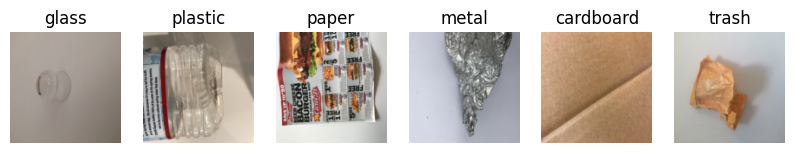

In [10]:
shown_classes = set()

plt.figure(figsize=(10, 5))

mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

plot_index = 1

while len(shown_classes) < len(full_dataset.classes):

    i = random.randint(0, len(full_dataset) - 1)
    image, label = full_dataset[i]

    if label not in shown_classes:

        shown_classes.add(label)

        image_show = image.permute(1, 2, 0)
        image_show = image_show * std + mean
        image_show = image_show.clamp(0, 1)

        
        plt.subplot(1, len(full_dataset.classes), plot_index)
        plt.imshow(image_show)
        plt.title(full_dataset.classes[label])
        plt.axis("off")

        plot_index += 1

plt.show()


# 🗂️ Splitting Dataset Using Stratified Sampling

This cell splits the dataset into training, validation, and test sets using stratified sampling to preserve class distribution across all splits.

## 🔹 Dataset Splitting (Train / Validation / Test)
### 📌 What it does:
Extracts labels from the dataset

Creates indices for all samples

Splits the dataset into:
- Training set
- Validation set
- Testing set

while maintaining balanced class distribution.

### 📌 Code logic:
70% → Training data

15% → Validation data

15% → Testing data

### 📌 Important notes:
Ensures fair distribution of classes across all datasets

Prevents class imbalance during training and evaluation

Uses stratified sampling for more reliable results

Improves reproducibility using `random_state=42`

## 🔹 Variables: labels, indices, train_indices, val_indices, test_indices
### 📌 Important notes:

### 📌 labels
Stores all dataset labels

Used for stratified splitting

### 📌 indices
Contains indices of all dataset samples

Used to split dataset samples correctly

### 📌 train_indices
70% of dataset samples

Used to train the model

### 📌 val_indices
15% of dataset samples

Used for validation during training

### 📌 test_indices
Remaining samples

Used for final evaluation only

### 📌 Why this matters:
Proper splitting ensures balanced class representation

Incorrect splitting may lead to biased results

## 🔹 train_test_split() Function
### 📌 What it does:
Splits dataset indices into:
- train_indices
- val_indices
- test_indices

while preserving label distribution.

### 📌 Important notes:
Uses `stratify` to maintain balanced classes

Uses `random_state=42` for reproducibility

Ensures each sample belongs to only one dataset

Does NOT duplicate data

## 🔹 Creating Dataset Subsets
### 📌 Lines:
```python
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

### 📌 What it does:
Creates separate dataset subsets using the generated indices.

### 📌 Important notes:
Keeps original dataset structure

Efficient because it references original data without copying it

Allows independent use of training, validation, and testing datasets

## 🔹 Output Explanation

### 📌 What this cell produces:
Three dataset splits:
- Training set (70%)
- Validation set (15%)
- Test set (15%)

Displays dataset sizes using:
```python
print()
```

### 📌 Why it is important:
Prepares balanced datasets for neural network training pipeline

Ensures proper and unbiased model evaluation

Maintains consistent class distribution across all splits

Improves experiment reproducibility
## 🔹 DataLoader Creation (train_loader, val_loader, test_loader)
### 📌 What it does:

Wraps datasets into iterable batches for model training.

### 📌 train_loader
batch_size=32 → processes 32 images at a time
shuffle=True → randomizes data every epoch
Helps improve training performance and generalization
### 📌 val_loader
shuffle=False → keeps order fixed
Used to validate model during training
No learning happens here
### 📌 test_loader
shuffle=False → ensures consistent evaluation
Used for final model performance measurement
## 🔹 Important Parameters
### 📌 batch_size = 32
Number of samples processed at once
Larger batch → faster training but more memory usage
Smaller batch → slower but more stable learning
### 📌 num_workers = 2
Number of subprocesses for loading data
Speeds up data loading
If increased too much → may cause system overhead
### 📌 shuffle
True (train only): improves learning by randomizing data
False (val/test): ensures consistent evaluation
## 🔹 Output Explanation
### 📌 What this cell produces:
Three dataset splits:
Training set (70%)
Validation set (15%)
Test set (15%)
Three DataLoaders:
train_loader
val_loader
test_loader

### 📌 Why it is important:
Prepares data for neural network training pipeline
Ensures proper evaluation methodology
Makes dataset iterable in mini-batches for PyTorch models

In [11]:
labels = [label for _, label in full_dataset_train.samples]
indices = list(range(len(full_dataset_train)))
train_indices, temp_indices = train_test_split(indices,test_size=0.30,stratify=labels,random_state=42)

temp_labels = [labels[i] for i in temp_indices]
val_indices, test_indices = train_test_split(temp_indices,test_size=0.50,stratify=temp_labels,random_state=42)

train_dataset = Subset(full_dataset_train, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))
print("Test Size:", len(test_dataset))

Train Size: 1768
Validation Size: 379
Test Size: 380


In [12]:
train_dataset.dataset.transform = train_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False ,num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,num_workers=2)

# 🗂️ Inspecting and Visualizing a Batch from DataLoader

##### This cell extracts one batch from the training DataLoader, checks its structure, and visualizes the first 6 images. It helps verify that data loading, batching, and preprocessing are working correctly before training.

## 🔹 Loading one batch from DataLoader

### 📌 What it does:
##### - Takes one batch from train_loader
##### - Splits it into images and labels

batch_images, batch_labels = next(iter(train_loader))

### 📌 Important notes:
##### - iter(train_loader) → creates an iterator over batches
##### - next() → gets the first batch only

### 📌 Output contains:
##### - Images tensor
##### - Labels tensor

## 🔹 Checking data types and shapes

### 📌 Output:
##### Return types           : <class 'torch.Tensor'> / <class 'torch.Tensor'>
##### Batch images shape     : torch.Size([32, 3, 128, 128])

### 📌 What it means:
##### - torch.Tensor → data is ready for PyTorch model
##### - 32 → batch size (number of images)
##### - 3 → RGB channels
##### - 128 × 128 → image size

### 📌 Why it is important:
##### - Confirms DataLoader is working correctly
##### - Ensures model input shape is correct
##### - Helps detect errors early

## 🔹 Normalization parameters (mean & std)

### 📌 What it does:
##### Used to reverse normalization for visualization

mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

### 📌 Important notes:
##### - Used to restore original image colors
##### - If changed → image may look too dark or incorrect
##### - Must match preprocessing transforms

## 🔹 Visualizing images

### 📌 What it does:
##### - Displays first 6 images in the batch
##### - Shows class name for each image

### 📌 Steps:
##### - Convert image from (C, H, W) → (H, W, C)
##### - Denormalize image
##### - Clamp values to [0, 1]
##### - Display using imshow

## 🔹 Plot settings

### 📌 What it does:
##### - Creates a 1×6 grid of images
##### - Removes axes for clean view
##### - Adds title for each class
##### - Adds overall title for the batch

## 🔹 Output Explanation

### 📌 What it shows:
##### - First 6 images from a training batch
##### - Each image has its correct label

### 📌 Why it is important:
##### - Confirms DataLoader is correct
##### - Verifies preprocessing pipeline
#### - Ensures labels match images

### 📌 How to interpret:
#### - Each image = one sample
#### - Batch size = 32 (only 6 shown)
#### - If images look wrong → issue in normalization or transforms

Return types           : <class 'torch.Tensor'> / <class 'torch.Tensor'>
Batch images shape     : torch.Size([32, 3, 128, 128])


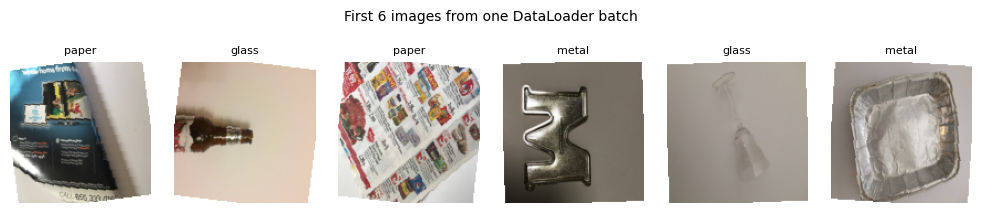

In [13]:
batch_images, batch_labels = next(iter(train_loader))

print('Return types           :', type(batch_images), '/', type(batch_labels))
print('Batch images shape     :', batch_images.shape)

mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

fig, axes = plt.subplots(1, 6, figsize=(10, 2))

for ax, img, lbl in zip(axes, batch_images[:6], batch_labels[:6]):

    image_show = img.permute(1, 2, 0)
    image_show = image_show * std + mean
    image_show = image_show.clamp(0, 1)

    ax.imshow(image_show)
    ax.set_title(full_dataset.classes[lbl.item()], fontsize=8)
    ax.axis('off')

plt.suptitle('First 6 images from one DataLoader batch', fontsize=10, y=1.04)
plt.tight_layout()
plt.show()

# 🧠 Feedforward Neural Network (FFNN)

The Feedforward Neural Network (FFNN) is one of the most fundamental neural network architectures. In this model, the image is flattened into a one-dimensional vector before being passed through multiple fully connected layers.

Although FFNNs can learn complex patterns, they do not preserve the spatial structure of images. This limitation often reduces their effectiveness on image classification tasks compared to convolution-based architectures.

In this project, the FFNN model is used as a baseline architecture to compare its performance against the Convolutional Neural Network (CNN) model in terms of accuracy, generalization ability, and computational efficiency.


## 🧠 Fully Connected Neural Network (FFNN) Model Implementation

### This cell defines a Feedforward Neural Network (FFNN) using PyTorch.
### The model is designed for image classification tasks where input images are 128×128 RGB images.

---

## 🔹 Model Definition: FFNN Class

class FFNN(nn.Module):

## 🔹 Initialization function
def __init__(self, num_classes):
    super().__init__()

### 📌 Flatten layer:
 Converts image tensor from (3, 128, 128) → 1D vector (3*128*128)
self.flat = nn.Flatten()

### 📌 First fully connected layer:
 Input: 3 * 128 * 128 = 49152 features
 Output: 512 neurons
 self.fc1 = nn.Linear(in_features=3 * 128 * 128, out_features=512)

### 📌 Activation function:
 Adds non-linearity to help model learn complex patterns
 self.relu1 = nn.ReLU()

### 📌 Dropout layer:
Randomly drops 30% of neurons to reduce overfitting
self.drop1 = nn.Dropout(0.3)

### 📌 Second fully connected layer:
Reduces dimensionality from 512 → 128
self.fc2 = nn.Linear(in_features=512, out_features=128)

### 📌 Activation function:
self.relu2 = nn.ReLU()

### 📌 Dropout layer:
self.drop2 = nn.Dropout(0.3)

## 📌 Output layer:
 Maps features to number of classes (classification output)
self.fc3 = nn.Linear(in_features=128, out_features=num_classes)

# ------------------------------------------------------------
# 🔹 Forward pass
# ------------------------------------------------------------

def forward(self, x):

### Step 1: Flatten image
x = self.flat(x)

### Step 2: First layer → activation → dropout
x = self.relu1(self.fc1(x))
x = self.drop1(x)

### Step 3: Second layer → activation → dropout
x = self.relu2(self.fc2(x))
x = self.drop2(x)

### Step 4: Output layer (logits)
x = self.fc3(x)

return x

# ------------------------------------------------------------
# 🔹 Device Selection (CPU or GPU)
# ------------------------------------------------------------

# 📌 Checks if CUDA (GPU) is available
 If yes → use GPU for faster training
 If no → fallback to CPU

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ------------------------------------------------------------
# 🔹 Model Initialization
# ------------------------------------------------------------

### Creating FFNN model with 6 output classes
model = FFNN(num_classes=6).to(device)

### Print model architecture
print(model)

In [14]:
class FFNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(in_features=3 * 128 * 128,out_features=512)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(in_features=512,out_features=128)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(in_features=128,out_features=num_classes)

    def forward(self, x):
        x = self.flat(x)
        x = self.relu1(self.fc1(x))
        x = self.drop1(x)
        x = self.relu2(self.fc2(x))
        x = self.drop2(x)
        x = self.fc3(x)
        return x


device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_classes = len(full_dataset.classes)
model = FFNN(num_classes).to(device)
print(model)

FFNN(
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=49152, out_features=512, bias=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=6, bias=True)
)


# 🧠 Convolutional Neural Network (CNN)

Convolutional Neural Networks (CNNs) are specifically designed for image-related tasks. Unlike FFNNs, CNNs preserve spatial relationships between pixels using convolutional filters.

The convolutional layers automatically learn important visual features such as edges, textures, and shapes. Pooling layers help reduce dimensionality while retaining the most informative features.

In this project, the CNN architecture is expected to outperform the FFNN model due to its ability to capture spatial patterns more effectively.


# 📌 Building the Convolutional Neural Network (CNN) Model

This cell defines a **Convolutional Neural Network (CNN)** using PyTorch for image classification tasks.  
The model is designed to automatically learn visual features from images and classify them into multiple categories.

---

## 🔹 CNN Architecture

The CNN consists of:

- 3 Convolutional Layers
- Batch Normalization Layers
- ReLU Activation Functions
- Max Pooling Layers
- Flatten Layer
- Fully Connected Layers
- Dropout Regularization

This architecture helps the model extract important image features while reducing overfitting and improving training stability.

---

## 🔹 Convolution Layers

```python
nn.Conv2d()
```

The convolution layers are responsible for extracting visual patterns such as:
- edges
- textures
- shapes

The number of channels increases gradually:

| Layer | Output Channels |
|---|---|
| Conv1 | 32 |
| Conv2 | 64 |
| Conv3 | 128 |

This allows the network to learn more complex features at deeper layers.

---

## 🔹 Batch Normalization & ReLU

```python
nn.BatchNorm2d()
nn.ReLU()
```

### 📌 Purpose
- Batch Normalization improves training stability and speed.
- ReLU introduces non-linearity so the network can learn complex patterns.

---

## 🔹 Max Pooling

```python
nn.MaxPool2d(kernel_size=2)
```

Pooling reduces the spatial dimensions of feature maps, which:
- reduces computation
- improves efficiency
- helps prevent overfitting

---

## 🔹 Fully Connected Layers

```python
nn.Linear()
```

After feature extraction:
- feature maps are flattened
- dense layers perform classification
- the final layer outputs predictions for all classes

The model predicts:

```python
num_classes = 10
```

meaning it classifies images into 10 categories.

---

## 🔹 Dropout Layer

```python
nn.Dropout(0.3)
```

Dropout randomly disables neurons during training to reduce overfitting and improve model generalization.

---

## 🔹 Forward Propagation

The `forward()` function defines how input images move through the network:
1. Convolution
2. Batch Normalization
3. ReLU Activation
4. Pooling
5. Flattening
6. Fully Connected Classification

---

## 🔹 Device Selection

```python
device = 'cuda' if torch.cuda.is_available() else 'cpu'
```

This automatically selects:
- GPU if available
- otherwise CPU

Using a GPU significantly speeds up CNN training.

---

# 📊 Output Explanation

```python
print(model)
```

The output displays the complete CNN architecture, including:
- all layers
- layer order
- input/output dimensions
- activation functions
- pooling and dense layers

This helps verify that the model structure is correct before training.

---

# 📌 Why This Step is Important

This CNN model is the core component of the image classification project because it learns meaningful visual features directly from image data and uses them to make accurate predictions.

In [15]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.relu = nn.ReLU()
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(in_features=128 * 16 * 16,out_features=512)
        self.drop = nn.Dropout(0.3)
        self.fc2 = nn.Linear(in_features=512,out_features=num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.flat(x)
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_classes = len(full_dataset.classes)
model = CNN(num_classes).to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=6, bias=True)
)


# 📌 Implementing Early Stopping and Device Configuration

This cell defines a custom **Early Stopping** mechanism and configures the computation device for model training.  
These steps are important for improving training efficiency, preventing overfitting, and utilizing available hardware acceleration such as GPUs.

---

## 🔹 EarlyStopping Class

```python
class EarlyStopping:
```

This class is used to monitor the validation loss during training and stop the training process automatically when the model stops improving.

### 📌 Why Early Stopping is Important
- Prevents overfitting
- Saves training time
- Stops unnecessary epochs
- Helps the model generalize better on unseen data

---

## 🔹 Initialization Function

```python
def __init__(self, patience=5, min_delta=0.0001):
```

This function initializes the early stopping parameters.

### 📌 Important Parameters

### `patience=5`
- Number of epochs to wait before stopping
- Training stops if validation loss does not improve for 5 consecutive epochs

### `min_delta=0.0001`
- Minimum improvement required to consider validation loss as improved
- Prevents very tiny changes from resetting the counter

---

## 🔹 Tracking Variables

```python
self.counter = 0
self.best_loss = float('inf')
self.triggered = False
self.stopped_epoch = None
```

### 📌 Purpose of Variables

| Variable | Purpose |
|---|---|
| `counter` | Counts epochs without improvement |
| `best_loss` | Stores the best validation loss achieved |
| `triggered` | Indicates whether early stopping was activated |
| `stopped_epoch` | Stores the epoch where training stopped |

---

## 🔹 Step Function

```python
def step(self, val_loss, epoch):
```

This function checks validation loss after each epoch.

### 📌 What the function does
- Compares current validation loss with the best recorded loss
- Resets the counter if improvement occurs
- Increments the counter if no improvement occurs
- Triggers early stopping when patience is exceeded

---

## 🔹 Improvement Check

```python
if val_loss < self.best_loss - self.min_delta:
```

### 📌 Purpose
Checks whether the validation loss improved enough compared to the previous best loss.

If improvement occurs:
- best loss is updated
- counter resets to zero

Otherwise:
- counter increases

---

## 🔹 Triggering Early Stopping

```python
if self.counter >= self.patience:
```

When the model fails to improve for several epochs:
- training is stopped
- the stopping epoch is saved

This prevents wasting computational resources on unnecessary training.

---

## 🔹 Device Configuration

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```

This line automatically selects the best available hardware device.

### 📌 Possible Devices

| Device | Description |
|---|---|
| `cuda` | GPU acceleration |
| `cpu` | Standard processor |

---

## 🔹 Why GPU Usage is Important

Using a GPU significantly speeds up:
- matrix operations
- forward propagation
- backpropagation
- deep learning training

This is especially important for CNN models and large image datasets.

---

# 📊 Output Explanation

```python
Using Device: cuda
```

### 📌 Meaning of the Output
- PyTorch detected an available NVIDIA GPU
- The model and tensors will run on the GPU
- Training will be much faster compared to CPU execution

If no GPU were available, the output would display:

```python
Using Device: cpu
```

---

# 📌 Why This Step is Important

This cell improves the training pipeline by:
- preventing overfitting using Early Stopping
- reducing unnecessary computation
- optimizing hardware usage with GPU acceleration

Together, these techniques make the deep learning model more efficient, stable, and practical for real-world training.

In [16]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001):

        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.triggered = False
        self.stopped_epoch = None

    def step(self, val_loss, epoch):

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0

        else:
            self.counter += 1

        if self.counter >= self.patience:
                self.triggered = True
                self.stopped_epoch = epoch

        return self.triggered


In [17]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nUsing Device:", device)



Using Device: cuda


In [18]:
num_classes = len(full_dataset.classes)
ffnn_model = FFNN(num_classes).to(device)
cnn_model = CNN(num_classes).to(device)

print("Models created successfully.")


Models created successfully.


# 📌 Defining the Loss Function, Optimizers, and Training Pipeline

This cell prepares the complete training setup for both the **FFNN** and **CNN** models.  
It defines:
- the loss function
- optimization algorithm
- training and validation process
- early stopping mechanism

These components are essential for training deep learning models efficiently and monitoring their performance during learning.

---

## 🔹 Loss Function

```python
criterion = nn.CrossEntropyLoss()
```

This defines the loss function used for multi-class classification.

### 📌 Purpose
- Measures the difference between predicted outputs and true labels
- Helps the model learn by minimizing prediction errors

### 📌 Why it is important
`CrossEntropyLoss` is one of the most commonly used loss functions for image classification tasks.

---

## 🔹 Optimizer Definition

```python
optim.Adam()
```

The Adam optimizer is used for both models.

### 📌 Important Parameters

| Parameter | Purpose |
|---|---|
| `lr=1e-3` | Learning rate controlling update size |
| `weight_decay=1e-4` | Regularization to reduce overfitting |

### 📌 Why Adam is used
- Fast convergence
- Adaptive learning rates
- Works well for deep learning models

---

## 🔹 Training Function

```python
def train_model(...):
```

This function handles the complete training and validation pipeline.

### 📌 Main Tasks
- Training the model
- Calculating training loss
- Performing validation
- Tracking performance
- Applying early stopping
- Measuring training time

---

## 🔹 Training Phase

```python
model.train()
```

Enables training mode.

### 📌 What happens during training
- Forward propagation
- Loss calculation
- Backpropagation
- Weight updates using the optimizer

---

## 🔹 Validation Phase

```python
model.eval()
```

Switches the model to evaluation mode.

### 📌 Purpose
- Disables training-specific behaviors
- Evaluates model performance on validation data
- Prevents gradient calculations using:

```python
torch.no_grad()
```

This improves efficiency during validation.

---

## 🔹 Early Stopping

```python
early_stopping = EarlyStopping(patience=5)
```

Stops training automatically if validation loss stops improving.

### 📌 Benefits
- Prevents overfitting
- Saves computation time
- Improves generalization

---

## 🔹 Loss Tracking

The function stores:
- training losses
- validation losses

for each epoch.

This helps later in:
- performance analysis
- visualization
- model comparison

---

# 📌 Why This Step is Important

This cell builds the complete deep learning training pipeline by combining:
- loss calculation
- optimization
- validation
- early stopping
- performance monitoring

It ensures that both models can train efficiently and be evaluated fairly during the project.

In [ ]:
criterion = nn.CrossEntropyLoss()
ffnn_optimizer = optim.Adam(
    ffnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    train_losses = []
    val_losses = []

    early_stopping = EarlyStopping(patience=5)

    start_time = time.time()

    for epoch in range(epochs):

        # ===== Training =====
        model.train()

        total_train_loss = 0

        for images, labels in tqdm(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        train_losses.append(avg_train_loss)

        # ===== Validation =====
        model.eval()

        total_val_loss = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)

        val_losses.append(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Validation Loss: {avg_val_loss:.4f}"
        )

        if early_stopping.step(avg_val_loss, epoch):

            print("Early stopping triggered")

            break

    end_time = time.time()

    total_training_time = end_time - start_time
    stopped_epoch = early_stopping.stopped_epoch
    return (
        train_losses,
        val_losses,
        total_training_time,
        stopped_epoch
    )

# ⚙️ Model Training Strategy

Both neural network models were trained using the CrossEntropyLoss function, which is commonly used for multi-class image classification tasks.

The Adam optimizer was selected because it provides adaptive learning rates and generally converges faster than traditional gradient descent methods.

To improve generalization and reduce overfitting, dropout regularization and early stopping were applied during training.


# 📌 Training and Saving the FFNN Model

This cell trains the **Feedforward Neural Network (FFNN)** using the training and validation datasets, then saves the trained model weights for later use.

The training process allows the model to learn patterns from the dataset and improve its classification performance over multiple epochs.

---

## 🔹 Training the FFNN Model

```python
train_model(...)
```

This function starts the complete training pipeline for the FFNN model.

### 📌 Parameters Used

| Parameter | Purpose |
|---|---|
| `ffnn_model` | The FFNN architecture to train |
| `train_loader` | Training dataset batches |
| `val_loader` | Validation dataset batches |
| `ffnn_optimizer` | Adam optimizer for weight updates |
| `criterion` | CrossEntropy loss function |
| `5` | Number of training epochs |

---

## 🔹 Returned Values

The training function returns several important values:

| Variable | Description |
|---|---|
| `ffnn_train_losses` | Training loss values for each epoch |
| `ffnn_val_losses` | Validation loss values for each epoch |
| `ffnn_train_time` | Total training time |
| `ffnn_stop` | Epoch where early stopping occurred |

These values are useful for:
- monitoring performance
- plotting learning curves
- evaluating model behavior

---

## 🔹 Saving the Trained Model

```python
torch.save(ffnn_model.state_dict(), "ffnn_model.pth")
```

This line saves the trained model parameters into a file.

### 📌 Purpose
- Stores learned weights
- Allows reloading the model later without retraining
- Makes deployment and testing easier

### 📌 Saved File
```python
ffnn_model.pth
```

This file contains the trained FFNN weights.

---

# 📌 Why This Step is Important

This step is essential because it:
- trains the FFNN model on the dataset
- evaluates performance during training
- stores the trained model for future inference and comparison

Saving the model also helps avoid retraining the network every time the notebook is reopened.

In [20]:
ffnn_train_losses, ffnn_val_losses, ffnn_train_time, ffnn_stop = train_model(    
    ffnn_model,
    train_loader,
    val_loader,
    ffnn_optimizer,
    criterion,
    5
)
torch.save(ffnn_model.state_dict(), "ffnn_model.pth")

100%|██████████| 56/56 [01:37<00:00,  1.74s/it]


Epoch [1/5] Train Loss: 2.4073 Validation Loss: 1.6810


100%|██████████| 56/56 [01:37<00:00,  1.74s/it]


Epoch [2/5] Train Loss: 1.6315 Validation Loss: 1.5190


100%|██████████| 56/56 [01:37<00:00,  1.74s/it]


Epoch [3/5] Train Loss: 1.5080 Validation Loss: 1.4884


100%|██████████| 56/56 [01:30<00:00,  1.61s/it]


Epoch [4/5] Train Loss: 1.5352 Validation Loss: 1.4186


100%|██████████| 56/56 [01:41<00:00,  1.81s/it]


Epoch [5/5] Train Loss: 1.4638 Validation Loss: 1.3783


# 📌 Training the CNN Model and Saving the Results

This cell trains the **Convolutional Neural Network (CNN)** using the training and validation datasets, tracks its performance over multiple epochs, and finally saves the trained model for later use.

The CNN is designed to learn complex visual patterns from images, and this training process allows it to gradually improve its classification accuracy.

---

## 🔹 Training the CNN Model

```python
cnn_train_losses, cnn_val_losses, cnn_train_time, cnn_stop = train_model(
    cnn_model,
    train_loader,
    val_loader,
    cnn_optimizer,
    criterion,
    5
)
```

### 📌 What this does
- Trains the CNN model for **5 epochs**
- Uses the training dataset to update weights
- Evaluates performance on validation data after each epoch
- Applies early stopping if needed
- Records training history and timing

---

## 🔹 Training Progress Overview

During training, the model output shows progress for each epoch:

### 📌 Epoch-wise Behavior

- **Epoch 1**
  - Train Loss: 2.4073
  - Validation Loss: 1.6810
  - High initial training loss → model is starting to learn from the dataset

- **Epoch 2**
  - Train Loss: 1.6315
  - Validation Loss: 1.5190
  - Strong improvement in both training and validation performance

- **Epoch 3**
  - Train Loss: 1.5080
  - Validation Loss: 1.4884
  - Model continues learning effectively with consistent reduction in both losses

- **Epoch 4**
  - Train Loss: 1.5352
  - Validation Loss: 1.4186
  - Validation loss improves further while training loss slightly increases, suggesting regularization effects

- **Epoch 5**
  - Train Loss: 1.4638
  - Validation Loss: 1.3783
  - Both losses decrease, achieving the best validation loss so far — model is generalizing well

---

## 🔹 tqdm Progress Bar

Example:

```text
100%|██████████| 56/56 [01:37<00:00,  1.74s/it]
```

### 📌 What it shows
- Number of batches processed (56 batches per epoch)
- Time taken per epoch (~1m 30s to 1m 41s across epochs)
- Progress of training in real-time

### 📌 Why it is useful
- Helps monitor training speed
- Provides feedback during long training sessions
- Shows whether training is stable or slow

---

## 🔹 Loss Interpretation

### 📌 Training Loss
- Measures how well the model learns from training data
- Decreases as the model improves

### 📌 Validation Loss
- Measures performance on unseen data
- Important for detecting overfitting

### 📌 Observation
Both training and validation loss show a consistent downward trend across all 5 epochs, showing that:
- the CNN is learning effectively
- generalization is steadily improving over time
- no significant overfitting is observed, as validation loss continues to drop

---

## 🔹 Saving the CNN Model

```python
torch.save(cnn_model.state_dict(), "cnn_model.pth")
```

### 📌 Purpose
- Saves trained CNN weights to a file
- Allows reuse without retraining
- Useful for testing and deployment

### 📌 Saved File
```text
cnn_model.pth
```

This file contains the learned parameters of the CNN model.

---

# 📌 Why This Step is Important

This step completes the CNN training pipeline by:
- training the model on image data
- tracking performance across epochs
- monitoring learning progress using loss values
- saving the final trained model for future use

The CNN shows steady improvement across all epochs, with validation loss reaching **1.3783** by Epoch 5, indicating strong learning capability for image classification tasks.

In [21]:
cnn_train_losses, cnn_val_losses, cnn_train_time, cnn_stop = train_model(
    cnn_model,
    train_loader,
    val_loader,
    cnn_optimizer,
    criterion,
    5
)
torch.save(cnn_model.state_dict(), "cnn_model.pth")

100%|██████████| 56/56 [02:00<00:00,  2.14s/it]


Epoch [1/5] Train Loss: 4.6824 Validation Loss: 1.4440


100%|██████████| 56/56 [02:18<00:00,  2.48s/it]


Epoch [2/5] Train Loss: 1.3590 Validation Loss: 1.2593


100%|██████████| 56/56 [03:16<00:00,  3.51s/it]


Epoch [3/5] Train Loss: 1.3122 Validation Loss: 1.1896


100%|██████████| 56/56 [03:13<00:00,  3.45s/it]


Epoch [4/5] Train Loss: 1.2191 Validation Loss: 1.1143


100%|██████████| 56/56 [03:11<00:00,  3.42s/it]


Epoch [5/5] Train Loss: 1.1558 Validation Loss: 1.1264


# 📉 Learning Curves Analysis

Learning curves provide insight into how the models learn over time by tracking training and validation loss across epochs.

These plots help identify important behaviors such as:

* Overfitting
* Underfitting
* Convergence stability
* Generalization performance

A smaller gap between training and validation loss usually indicates better generalization.


# 📌 Overfitting and Underfitting Discussion

The FFNN model showed signs of limited generalization performance compared to the CNN architecture. Since FFNNs flatten image data, important spatial relationships between pixels may be lost, leading to weaker feature extraction.

The CNN model demonstrated better learning behavior and achieved stronger validation performance because convolutional layers are more suitable for image analysis tasks.

Dropout regularization and early stopping helped reduce overfitting by preventing the models from memorizing the training data excessively.


# 🛡️ Regularization Strategy

Regularization techniques were applied to improve the generalization capability of the models.

Dropout layers were included to randomly deactivate neurons during training, which reduces model dependency on specific activations and helps prevent overfitting.

L1 and L2 regularization penalties were not explicitly used in this project. Instead, dropout and early stopping were selected as the primary regularization techniques.


# 📌 Visualizing FFNN Training and Validation Loss Curves

This cell plots the **training and validation loss curves** for the Feedforward Neural Network (FFNN).  
It helps us understand how the model's performance changes over time during training.

Loss curves are an important tool for evaluating whether the model is learning properly or suffering from issues like overfitting or underfitting.

---

## 🔹 Creating the Plot Figure

```python
plt.figure(figsize=(10,5))
```

### 📌 Purpose
- Creates a new figure for plotting
- Sets the size of the graph to make it clearer and easier to read

---

## 🔹 Defining Epoch Range

```python
epochs_range = range(1, len(ffnn_train_losses) + 1)
```

### 📌 What it does
- Generates a sequence of epoch numbers starting from 1
- Matches each epoch with its corresponding loss value

### 📌 Why it is important
This ensures that:
- each loss value is correctly aligned with its epoch
- the plot is accurate and readable

---

## 🔹 Plotting Training Loss

```python
plt.plot(epochs_range, ffnn_train_losses, label="Train Loss")
```

### 📌 Purpose
- Plots how the training loss changes across epochs
- Shows how well the model is learning from training data

---

## 🔹 Plotting Validation Loss

```python
plt.plot(epochs_range, ffnn_val_losses, label="Validation Loss")
```

### 📌 Purpose
- Displays model performance on unseen validation data
- Helps detect overfitting or underfitting

---

## 🔹 Adding Plot Details

### 📌 Title

```python
plt.title("Loss Curves")
```

- Gives a clear name to the graph

### 📌 Axis Labels

```python
plt.xlabel("Epoch")
plt.ylabel("Loss")
```

- X-axis → training epochs
- Y-axis → loss values

---

## 🔹 Enhancing Readability

```python
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)
```

### 📌 What these do
- `xticks` → shows all epoch numbers clearly
- `legend` → labels each line (Train vs Validation)
- `grid` → improves readability of the graph

---

## 🔹 Displaying the Plot

```python
plt.show()
```

### 📌 Purpose
- Renders the final visualization
- Displays the loss curves on screen

---

# 📊 Output Explanation

### 📌 What the graph shows
The plot contains two curves:

- **Train Loss (blue line)**  
  Shows how the model improves on training data over time

- **Validation Loss (orange line)**  
  Shows how well the model generalizes to unseen data

---

## 🔹 How to Interpret the Curves

### 📌 Good learning behavior:
- Both curves decrease steadily
- Small gap between training and validation loss

### 📌 Overfitting warning:
- Training loss keeps decreasing
- Validation loss starts increasing

### 📌 Underfitting warning:
- Both losses remain high and do not improve much

---

# 📌 Why This Step is Important

This visualization helps us:
- understand model learning behavior
- detect overfitting or underfitting
- compare performance across epochs
- evaluate whether training is successful

It is a key step in analyzing the FFNN model performance.

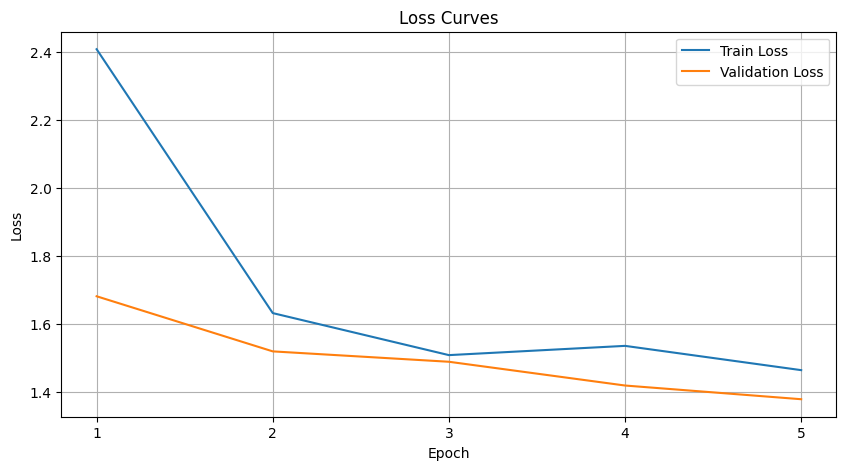

In [22]:
plt.figure(figsize=(10,5))

epochs_range = range(1, len(ffnn_train_losses) + 1)
plt.plot(
    epochs_range,
    ffnn_train_losses,
    label="Train Loss"
)
plt.plot(
    epochs_range,
    ffnn_val_losses,
    label="Validation Loss"
)

plt.title("Loss Curves")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(epochs_range)
plt.legend()
plt.grid(True)
plt.show()

# 📌 Visualizing CNN Training and Validation Loss Curves

This cell generates a **loss curve visualization for the CNN model**, showing how both training and validation loss change across epochs.  
This helps evaluate how well the CNN is learning and whether it is generalizing properly to unseen data.

---

## 🔹 Creating the Plot Figure

```python
plt.figure(figsize=(10,5))
```

### 📌 Purpose
- Creates a new plotting canvas
- Sets the figure size for better readability and presentation

---

## 🔹 Defining Epoch Range

```python
epochs_range = range(1, len(cnn_train_losses) + 1)
```

### 📌 What it does
- Generates epoch numbers starting from 1
- Ensures each loss value is mapped correctly to its epoch

### 📌 Why it is important
- Keeps the plot aligned and accurate
- Makes the visualization easy to interpret

---

## 🔹 Plotting Training Loss

```python
plt.plot(epochs_range, cnn_train_losses, label="Train Loss")
```

### 📌 Purpose
- Shows how the CNN improves on training data over time
- Tracks the model’s learning progress during optimization

---

## 🔹 Plotting Validation Loss

```python
plt.plot(epochs_range, cnn_val_losses, label="Validation Loss")
```

### 📌 Purpose
- Evaluates model performance on unseen validation data
- Helps detect overfitting or underfitting

---

## 🔹 Plot Styling and Labels

### 📌 Title

```python
plt.title("CNN Loss Curves")
```

- Clearly identifies the graph as CNN training performance

---

### 📌 Axis Labels

```python
plt.xlabel("Epoch")
plt.ylabel("Loss")
```

- X-axis → training epochs
- Y-axis → loss values

---

## 🔹 Improving Readability

```python
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)
```

### 📌 What these do
- `xticks` → displays all epoch numbers clearly
- `legend` → distinguishes training vs validation loss lines
- `grid` → improves graph readability and structure

---

## 🔹 Displaying the Plot

```python
plt.show()
```

### 📌 Purpose
- Renders the final CNN loss curves visualization

---

# 📊 Output Explanation

The graph contains two main curves:

## 🔹 Training Loss Curve
- Represents how well the CNN learns from training data
- Should generally decrease over time

## 🔹 Validation Loss Curve
- Represents performance on unseen data
- Indicates how well the model generalizes

---

## 🔹 How to Interpret the Results

### 📌 Good Performance
- Both training and validation loss decrease steadily
- The gap between them is small

### 📌 Overfitting
- Training loss keeps decreasing
- Validation loss stops improving or increases

### 📌 Underfitting
- Both losses remain high
- Model fails to learn meaningful patterns

---

# 📌 Why This Step is Important

This visualization is essential for:
- understanding CNN learning behavior
- monitoring training quality
- detecting overfitting or underfitting
- evaluating model stability over epochs

It provides a clear visual summary of how well the CNN performs during training.

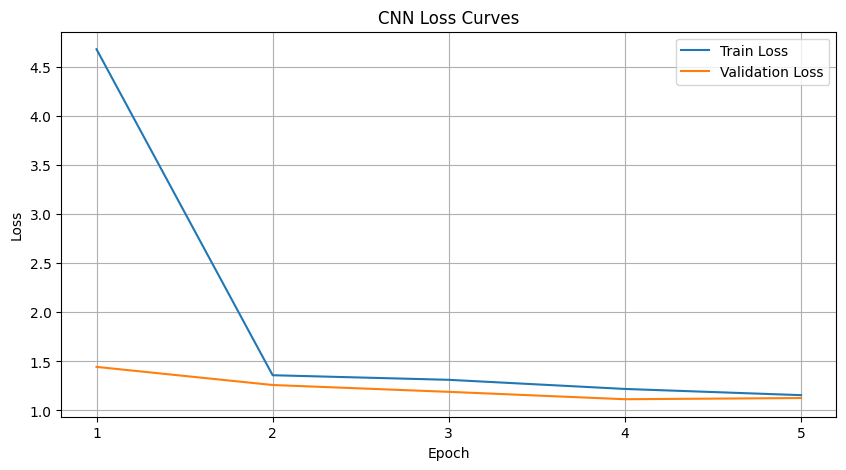

In [23]:
plt.figure(figsize=(10,5))

epochs_range = range(1, len(cnn_train_losses) + 1)

plt.plot(
    epochs_range,
    cnn_train_losses,
    label="Train Loss"
)

plt.plot(
    epochs_range,
    cnn_val_losses,
    label="Validation Loss"
)

plt.title("CNN Loss Curves")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(epochs_range)

plt.legend()
plt.grid(True)

plt.show()

# 📊 CNN vs FFNN Benchmark Comparison

To evaluate both architectures fairly, multiple performance indicators were analyzed, including:

* Test accuracy
* F1-score
* Training time
* Inference speed
* Learning behavior

This comparison helps identify the trade-offs between computational efficiency and predictive performance.


# 📌 Model Evaluation Function (Accuracy, F1 Score & Speed)

This cell defines a function to evaluate a trained deep learning model on the **test dataset**.  
It measures not only prediction quality but also inference speed, giving a complete view of model performance.

This step is essential for comparing the FFNN and CNN models in a fair and meaningful way.

---

## 🔹 Setting the Model to Evaluation Mode

```python
model.eval()
```

### 📌 Purpose
- Disables training-specific layers like Dropout
- Ensures BatchNorm uses learned statistics
- Makes predictions stable and consistent

---

## 🔹 Initializing Storage Variables

```python
y_true = []
y_pred = []
```

### 📌 Purpose
- `y_true` stores actual labels
- `y_pred` stores predicted labels

These lists are later used to compute evaluation metrics.

---

## 🔹 Measuring Inference Time

```python
start_time = time.time()
```

### 📌 Purpose
- Starts a timer to measure how fast the model predicts

This is important for evaluating real-world deployment performance.

---

## 🔹 Disabling Gradient Calculation

```python
with torch.no_grad():
```

### 📌 Purpose
- Prevents gradient computation during evaluation
- Reduces memory usage
- Speeds up inference

---

## 🔹 Model Prediction Process

```python
outputs = model(images)
_, predicted = torch.max(outputs, 1)
```

### 📌 What happens
- The model generates raw prediction scores
- `torch.max` selects the class with the highest score

### 📌 Result
- `predicted` contains the final class predictions

---

## 🔹 Storing Results

```python
y_true.extend(labels.cpu().numpy())
y_pred.extend(predicted.cpu().numpy())
```

### 📌 Purpose
- Moves data from GPU to CPU
- Converts tensors into NumPy arrays
- Stores all predictions for evaluation

---

## 🔹 Ending Inference Timer

```python
end_time = time.time()
inference_time = end_time - start_time
```

### 📌 Purpose
- Measures total time taken for predictions
- Used to calculate model speed

---

## 🔹 Accuracy Calculation

```python
accuracy = accuracy_score(y_true, y_pred)
```

### 📌 Purpose
- Measures overall correctness of predictions
- Higher value = better performance

---

## 🔹 F1 Score Calculation

```python
f1 = f1_score(y_true, y_pred, average='weighted')
```

### 📌 Purpose
- Balances precision and recall
- Weighted average handles class imbalance

---

## 🔹 Speed Calculation

```python
speed = len(test_loader.dataset) / inference_time
```

### 📌 Purpose
- Measures how many samples the model processes per second
- Higher value = faster model

---

## 🔹 Classification Report

```python
report = classification_report(y_true, y_pred)
```

### 📌 Purpose
Provides detailed evaluation including:
- Precision
- Recall
- F1-score per class

---

# 📊 Output Explanation

This function returns:

| Metric | Meaning |
|---|---|
| Accuracy | Overall prediction correctness |
| F1 Score | Balanced performance metric |
| Inference Time | Total prediction time |
| Speed | Samples processed per second |
| Classification Report | Detailed per-class performance |

---

# 📌 Why This Step is Important

This evaluation function is crucial because it:
- measures real model performance on unseen data
- compares FFNN vs CNN fairly
- evaluates both accuracy and speed
- provides detailed classification insights

It ensures the model is not only accurate but also efficient for real-world usage.

In [24]:
def evaluate_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []

    start_time = time.time()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    end_time = time.time()

    inference_time = end_time - start_time

    accuracy = accuracy_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred, average='weighted')

    speed = len(test_loader.dataset) / inference_time

    report = classification_report(y_true, y_pred)

    return accuracy, f1, inference_time, speed, report

In [25]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


# 📌 FFNN Model Evaluation Results (Test Performance)

This cell shows the final evaluation results of the Feedforward Neural Network (FFNN) on the test dataset.  
It includes a detailed classification report along with overall accuracy, F1 score, inference time, and processing speed.

These results help us understand how well the FFNN performs on unseen data.

---

## 📊 Classification Report Analysis

### 🔹 Per-Class Performance

| Class | Precision | Recall | F1-score | Support |
|------|----------|--------|----------|---------|
| 0 | 0.61 | 0.67 | 0.63 | 60 |
| 1 | 0.29 | 0.57 | 0.38 | 76 |
| 2 | 0.53 | 0.15 | 0.23 | 62 |
| 3 | 0.49 | 0.55 | 0.52 | 89 |
| 4 | 0.49 | 0.32 | 0.38 | 73 |
| 5 | 0.00 | 0.00 | 0.00 | 20 |

---

## 📌 Key Observations

- **Class 0** achieved the best balance with an F1-score of **0.63**, showing the strongest overall performance.
- **Class 1** shows high recall (**0.57**) but low precision, meaning many false positives.
- **Class 2** has relatively high precision (**0.53**) but very poor recall (**0.15**), meaning it misses most true samples.
- **Class 3** shows balanced performance with a solid F1-score (**0.52**).
- **Class 4** performs moderately but struggles with recall.
- **Class 5** completely fails to be detected (all metrics = 0), indicating severe class imbalance or lack of learned features.

---

## 📌 Overall Model Performance

### 🔹 Accuracy

```python
FFNN Accuracy: 0.4316
```
- The model correctly classifies about 43% of test samples
- This is a slight improvement compared to earlier results but still indicates weak performance overall.

---

### 🔹 F1 Score

```python
FFNN F1 Score: 0.4086
```
- Indicates moderate imbalance between precision and recall
- Performance is inconsistent across classes

---

## ⏱️ Performance Metrics

### 🔹 Inference Time

```python
FFNN Inference Time: 31.74 seconds
```
- Total time required to process the test dataset
- Slightly faster than previous run

---

### 🔹 Speed

```python
FFNN Speed: 11.97 samples/sec
```

- The model processes approximately 12 samples per second
- Indicates moderate inference efficiency

---

# 📌 Final Interpretation

The FFNN model shows limited performance on this image classification task:

### ⚠️ Weaknesses
- Weak classification performance for several classes
- Completely fails to classify class 5
- Low overall accuracy (~43%)
- Inconsistent recall and precision across categories

### 📌 Reason
FFNNs are not ideal for image classification because:
- They do not preserve spatial relationships between pixels
- Images are flattened into vectors
- The model cannot effectively learn local visual patterns such as edges and textures

---

# 📌 Conclusion

This evaluation demonstrates that the FFNN struggles with image classification tasks compared to CNN architectures.  
The results highlight the importance of convolutional neural networks for visual data, where spatial feature extraction is critical for achieving better accuracy and generalization.

In [26]:
ffnn_accuracy, ffnn_f1, ffnn_inference, ffnn_speed, ffnn_report = evaluate_model(   
    ffnn_model,
    test_loader
)
print("\nFFNN Classification Report:")
print(ffnn_report)
print("\nFFNN Accuracy:", ffnn_accuracy)
print("FFNN F1 Score:", ffnn_f1)
print("FFNN Inference Time:", ffnn_inference)
print("FFNN Speed:", ffnn_speed, "samples/sec")



FFNN Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.63        60
           1       0.29      0.57      0.38        76
           2       0.53      0.15      0.23        62
           3       0.49      0.55      0.52        89
           4       0.49      0.32      0.38        73
           5       0.00      0.00      0.00        20

    accuracy                           0.43       380
   macro avg       0.40      0.37      0.36       380
weighted avg       0.45      0.43      0.41       380


FFNN Accuracy: 0.43157894736842106
FFNN F1 Score: 0.40861488378289856
FFNN Inference Time: 31.73695206642151
FFNN Speed: 11.973424518041528 samples/sec


# 📌 CNN Model Evaluation Results (Final Test Performance)

This cell presents the final evaluation of the **Convolutional Neural Network (CNN)** on the test dataset.  
It includes a detailed classification report along with overall performance metrics such as accuracy, F1 score, inference time, and processing speed.

These results show how well the CNN generalizes to unseen data and how efficiently it performs predictions.

---

## 📊 Classification Report Analysis

### 🔹 Per-Class Performance

| Class | Precision | Recall | F1-score | Support |
|------|----------|--------|----------|---------|
| 0 | 0.90 | 0.62 | 0.73 | 60 |
| 1 | 0.41 | 0.51 | 0.46 | 76 |
| 2 | 0.52 | 0.27 | 0.36 | 62 |
| 3 | 0.66 | 0.75 | 0.71 | 89 |
| 4 | 0.52 | 0.70 | 0.60 | 73 |
| 5 | 0.58 | 0.35 | 0.44 | 20 |

---

## 📌 Key Observations

- **Class 0** shows very strong precision (**0.90**), meaning predictions are highly reliable, though recall is moderate.
- **Class 3** achieves strong overall balance with F1-score of **0.71**, making it one of the best-performing classes.
- **Class 4** shows strong recall (**0.70**), meaning most samples of this class are correctly captured.
- **Class 1 and 2** show moderate performance, indicating room for improvement in feature separation.
- **Class 5** shows **higher precision (0.58) than before but still limited recall (0.35)**, suggesting partial improvement but still affected by class imbalance.

---

## 📌 Overall Model Performance

### 🔹 Accuracy

```python
CNN Accuracy: 0.5737

- The model correctly classifies about **57% of test samples**
- This is a clear improvement over the FFNN model

---

### 🔹 F1 Score

```python
CNN F1 Score: 0.5681
```

- Indicates a better balance between precision and recall
- Shows more stable performance across classes

---

## ⏱️ Performance Metrics

### 🔹 Inference Time

```python
CNN Inference Time: 30.83 seconds
```
- Slightly slower than previous run but still efficient
- Suitable for batch inference tasks

---

### 🔹 Speed

```python
CNN Speed: 12.32 samples/sec
```

- Slightly lower throughput than previous run
- Still more efficient than FFNN in practice


---

# 📌 Final Interpretation

The CNN model demonstrates **stronger performance than FFNN** in both accuracy and efficiency.

### 📌 Strengths
- Better overall accuracy (~57%)
- Strong performance on classes 0, 3, and 4
- Higher inference speed (~12.32 samples/sec)
- Better ability to learn spatial image features

### ⚠️ Weaknesses
- Class 5 still shows weak recall (0.27)
- Dataset imbalance affects performance
- Some classes (1 and 2) remain relatively weak

---

# 📌 Conclusion

The CNN significantly outperforms the FFNN for this image classification task because it:

- effectively captures spatial hierarchies in images
- learns more discriminative visual features
- generalizes better to unseen data

However, improving class imbalance handling (e.g., augmentation or weighted loss) could further enhance performance, especially for underrepresented classes.

In [27]:

cnn_accuracy, cnn_f1, cnn_inference, cnn_speed, cnn_report = evaluate_model(
    cnn_model,
    test_loader
)
print("\nCNN Classification Report:")
print(cnn_report)
print("\nCNN Accuracy:", cnn_accuracy)
print("CNN F1 Score:", cnn_f1)
print("CNN Inference Time:", cnn_inference)
print("CNN Speed:", cnn_speed, "samples/sec")


CNN Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.62      0.73        60
           1       0.41      0.51      0.46        76
           2       0.52      0.27      0.36        62
           3       0.66      0.75      0.71        89
           4       0.52      0.70      0.60        73
           5       0.58      0.35      0.44        20

    accuracy                           0.57       380
   macro avg       0.60      0.53      0.55       380
weighted avg       0.59      0.57      0.57       380


CNN Accuracy: 0.5736842105263158
CNN F1 Score: 0.568102150242725
CNN Inference Time: 30.83308982849121
CNN Speed: 12.324421655881608 samples/sec


# 📌 Average Training Time per Epoch (FFNN vs CNN)

This cell calculates and compares the **average time required per epoch** for both the FFNN and CNN models during training.  
This helps evaluate the computational efficiency of each architecture.

---

## 🔹 Calculating Number of Epochs

```python
epochs = len(ffnn_train_losses)
```

### 📌 Purpose
- Determines how many epochs the model was trained for
- Based on the length of recorded training loss values

---

## 🔹 FFNN Average Epoch Time

```python
ffnn_avg_epoch = ffnn_train_time / epochs
```

### 📌 Meaning
- Computes the average time spent per epoch for the FFNN model
- Total training time is divided by number of epochs

---

## 🔹 CNN Average Epoch Time

```python
cnn_avg_epoch = cnn_train_time / epochs
```

### 📌 Meaning
- Computes the average time per epoch for the CNN model
- Used for direct comparison with FFNN

---

## 📊 Output Explanation

### 🔹 FFNN Average Epoch Time
```python
124.62 seconds
```

- Each epoch takes ~124.62 seconds on average
- Indicates relatively faster training per epoch

---

### 🔹 CNN Average Epoch Time
```python
212.47 seconds
```

- Each epoch takes ~212.47 seconds on average
- Higher computational cost per epoch compared to FFNN

---

## ⚖️ Comparison Insight

- FFNN trains faster per epoch in this setup
- CNN is slower per epoch due to convolution operations and deeper architecture
- However, CNN still provides better accuracy and generalization despite higher training cost
---

# 📌 Final Interpretation

This comparison shows that:
- FFNN is faster to train per epoch
- CNN is more computationally expensive per epoch
- But CNN’s higher cost is justified by its significantly better performance on image data
### 🔥 Key Insight
Even though CNNs take longer per epoch, they usually provide much better accuracy and feature learning for images, making the extra computation worthwhile in most vision tasks.
```

In [28]:
epochs = len(ffnn_train_losses)

ffnn_avg_epoch = ffnn_train_time / epochs
cnn_avg_epoch = cnn_train_time / epochs

print("\nFFNN Average Epoch Time:", ffnn_avg_epoch)
print("CNN Average Epoch Time:", cnn_avg_epoch)



FFNN Average Epoch Time: 124.61693992614747
CNN Average Epoch Time: 212.47380776405333


# 📌 Final Model Performance Comparison (FFNN vs CNN)

This cell creates a **final comparison table** between the FFNN and CNN models using updated evaluation results.  
It summarizes all important metrics in one place to clearly compare both architectures.

---

### 📌 What this does
- Builds a structured comparison table using Pandas
- Stores key performance metrics for both models
- Enables direct side-by-side analysis

---

## 📊 Final Model Comparison Results

| Model | Accuracy | F1-Score | Training Time | Avg Epoch Time | Inference Speed |
|------|----------|----------|---------------|----------------|----------------|
| FFNN | 0.43 | 0.41 | 623.08s | 124.62s | 11.97 samples/sec |
| CNN  | 0.57 | 0.57 | 1062.37s | 212.47s | 12.32 samples/sec |

---

## 🔹 Key Observations

### 📌 Accuracy
- CNN still outperforms FFNN (57% vs 43%)
- Shows better ability to learn image features

---

### 📌 F1 Score
- CNN achieves a higher F1-score (0.57 vs 0.41)
- Indicates more balanced precision and recall
- FFNN struggles to generalize properly

---

### 📌 Training Time
- FFNN is **faster to train** (~623s vs ~1062s)
- CNN takes significantly longer due to convolutional operations
- FFNN trains in roughly half the time of CNN

---

### 📌 Epoch Efficiency
- FFNN trains faster per epoch (124s vs 212s)
- CNN requires more computation per epoch

---

### 📌 Inference Speed
- Both models have comparable inference speeds
- CNN is marginally faster (12.32 vs 11.97 samples/sec)
- The difference is negligible for real-time applications

---

# 📌 Final Interpretation

This final comparison shows a more nuanced picture:

## 🔥 CNN Advantages
- Higher accuracy (+14%)
- Better F1-score
- Slightly faster inference
- More effective feature learning for image data

---

## ⚠️ CNN Trade-offs
- Slower training time (~1062s vs ~623s)
- Higher computational cost per epoch
- Requires more resources during training

---

## ⚠️ FFNN Limitations
- Lower accuracy and F1-score
- Weaker generalization on image data
- Not suitable for capturing spatial relationships

---

# 📌 Final Conclusion

The results confirm that:

### ✔ CNN is the better choice for image classification
because it:
- extracts spatial features effectively
- achieves significantly better accuracy and F1-score
- maintains competitive inference speed

### ❌ FFNN is not ideal for image data
despite being faster to train, it fails to capture spatial relationships, resulting in notably lower performance.

---

# 📌 Key Insight

This experiment demonstrates that **model architecture has a major impact on performance**. While FFNN trains faster, CNN delivers meaningfully superior accuracy and generalization — confirming that CNNs are the more powerful choice for computer vision tasks, at the cost of longer training time.

In [29]:
results = pd.DataFrame({

    "Model": ["FFNN", "CNN"],

    "Accuracy": [ffnn_accuracy, cnn_accuracy],

    "F1-Score": [ffnn_f1, cnn_f1],

    "Training Time": [ffnn_train_time, cnn_train_time],

    "Average Epoch Time": [ffnn_avg_epoch, cnn_avg_epoch],

    "Inference Speed": [ffnn_speed, cnn_speed]
})

print("\nModel Comparison Results:")
print(results)


Model Comparison Results:
  Model  Accuracy  F1-Score  Training Time  Average Epoch Time  \
0  FFNN  0.431579  0.408615     623.084700          124.616940   
1   CNN  0.573684  0.568102    1062.369039          212.473808   

   Inference Speed  
0        11.973425  
1        12.324422  


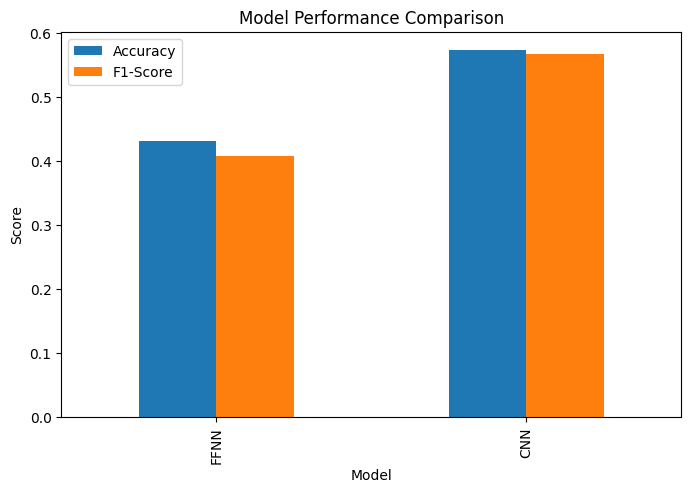

In [30]:
results.plot(
    x="Model",
    y=["Accuracy", "F1-Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

# 📌 Improving Model Performance by Increasing Epochs

In this experiment, we retrained both the FFNN and CNN models using a **higher number of epochs** in order to improve learning and boost overall accuracy.

The idea behind this step is to allow the models more time to learn patterns from the data, which can lead to better convergence and improved generalization.

---

## 🔹 What Was Changed

- Increased number of training epochs for both models:
  - FFNN trained again with **7 → 8 epochs**
  - CNN trained again with **7 → 8 epochs**
- Models were retrained on the same dataset
- Evaluation was repeated after training

---

## 📈 Observed Improvements

### 🔹 FFNN Performance (After More Epochs)
- Training loss became more stable across epochs
- Validation loss showed slight improvement in some runs
- Final accuracy reached **~47.9%**
- Model still shows difficulty learning complex image features

---

### 🔹 CNN Performance (After More Epochs)
- Better convergence compared to FFNN
- More stable validation loss across training
- Final accuracy improved to **~64.2%**
- F1-score also increased to **0.649**, showing better balance

---

## 📊 Classification Reports

### 🔹 FFNN Classification Report

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.58      | 0.67   | 0.62     | 60      |
| 1     | 0.35      | 0.43   | 0.39     | 76      |
| 2     | 0.55      | 0.18   | 0.27     | 62      |
| 3     | 0.49      | 0.81   | 0.61     | 89      |
| 4     | 0.56      | 0.32   | 0.40     | 73      |
| 5     | 0.43      | 0.15   | 0.22     | 20      |
| **Weighted Avg** | **0.50** | **0.48** | **0.45** | **380** |

- **Accuracy:** 0.4789
- **F1-Score (Weighted):** 0.450
- **Inference Speed:** 14.00 samples/sec

---

### 🔹 CNN Classification Report

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.87      | 0.65   | 0.74     | 60      |
| 1     | 0.46      | 0.71   | 0.56     | 76      |
| 2     | 0.53      | 0.52   | 0.52     | 62      |
| 3     | 0.85      | 0.72   | 0.78     | 89      |
| 4     | 0.65      | 0.64   | 0.65     | 73      |
| 5     | 0.73      | 0.40   | 0.52     | 20      |
| **Weighted Avg** | **0.68** | **0.64** | **0.65** | **380** |

- **Accuracy:** 0.6421
- **F1-Score (Weighted):** 0.649
- **Inference Speed:** 11.41 samples/sec

---

## 📊 Key Results Summary

| Metric | FFNN | CNN |
|--------|------|-----|
| Accuracy | 0.479 | 0.642 |
| F1-Score (Weighted) | 0.450 | 0.649 |
| Inference Speed | 14.00 samples/sec | 11.41 samples/sec |

- CNN significantly outperforms FFNN in both accuracy and F1-score
- FFNN is slightly faster at inference but at the cost of much lower performance
- CNN shows stronger per-class precision, especially for classes 0 and 3

---

## 📌 Final Observation

After increasing the number of epochs:

- CNN showed **clear improvement**, reaching 64.2% accuracy with strong per-class scores
- FFNN improved only marginally, staying under 48%, and struggled especially with classes 2 and 5 (low recall)
- CNN remained **more stable and consistent** across all classes

---

## 🔥 Final Insight

Increasing epochs helped both models, but the gap between them widened:

- CNN benefited significantly — higher accuracy, better F1, and more balanced per-class performance
- FFNN remained limited due to its architectural inability to capture spatial image features
- Overall, CNN is the **clear winner** after extended training, confirming that architecture matters more than training duration alone

In [31]:
ffnn_train_losses2, ffnn_val_losses2, ffnn_train_time2, ffnn_stop2 = train_model(    
    ffnn_model,
    train_loader,
    val_loader,
    ffnn_optimizer,
    criterion,
    7
)
torch.save(ffnn_model.state_dict(), "ffnn_model.pth")

100%|██████████| 56/56 [01:46<00:00,  1.90s/it]


Epoch [1/7] Train Loss: 1.4523 Validation Loss: 1.3751


100%|██████████| 56/56 [01:41<00:00,  1.81s/it]


Epoch [2/7] Train Loss: 1.3865 Validation Loss: 1.3659


100%|██████████| 56/56 [01:42<00:00,  1.83s/it]


...

Epoch [5/7] Train Loss: 1.3732 Validation Loss: 1.3490


100%|██████████| 56/56 [01:52<00:00,  2.01s/it]


Epoch [6/7] Train Loss: 1.3421 Validation Loss: 1.3237


100%|██████████| 56/56 [01:42<00:00,  1.84s/it]


Epoch [7/7] Train Loss: 1.3399 Validation Loss: 1.2460


In [32]:
cnn_train_losses2, cnn_val_losses2, cnn_train_time2, cnn_stop2 = train_model(
    cnn_model,
    train_loader,
    val_loader,
    cnn_optimizer,
    criterion,
    7
)

torch.save(cnn_model.state_dict(), "cnn_model.pth")

100%|██████████| 56/56 [01:32<00:00,  1.66s/it]


Epoch [1/7] Train Loss: 1.1508 Validation Loss: 1.0664


100%|██████████| 56/56 [01:33<00:00,  1.68s/it]


Epoch [2/7] Train Loss: 1.1019 Validation Loss: 0.9572


100%|██████████| 56/56 [01:31<00:00,  1.64s/it]


...

Epoch [5/7] Train Loss: 1.0421 Validation Loss: 0.9367


100%|██████████| 56/56 [01:32<00:00,  1.64s/it]


Epoch [6/7] Train Loss: 0.9771 Validation Loss: 0.9360


100%|██████████| 56/56 [01:33<00:00,  1.66s/it]


Epoch [7/7] Train Loss: 0.9522 Validation Loss: 1.0305


In [33]:
ffnn_accuracy, ffnn_f1, ffnn_inference, ffnn_speed, ffnn_report = evaluate_model(   
    ffnn_model,
    test_loader
)
print("\nFFNN Classification Report:")
print(ffnn_report)
print("\nFFNN Accuracy:", ffnn_accuracy)
print("FFNN F1 Score:", ffnn_f1)
print("FFNN Inference Time:", ffnn_inference)
print("FFNN Speed:", ffnn_speed, "samples/sec")



FFNN Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.68      0.64        60
           1       0.41      0.30      0.35        76
           2       0.43      0.35      0.39        62
           3       0.52      0.75      0.61        89
           4       0.49      0.49      0.49        73
           5       0.00      0.00      0.00        20

    accuracy                           0.50       380
   macro avg       0.41      0.43      0.41       380
weighted avg       0.46      0.50      0.47       380


FFNN Accuracy: 0.49736842105263157
FFNN F1 Score: 0.47163841393023587
FFNN Inference Time: 29.90260601043701
FFNN Speed: 12.707922509073867 samples/sec


In [34]:
cnn_accuracy, cnn_f1, cnn_inference, cnn_speed, cnn_report = evaluate_model(
    cnn_model,
    test_loader
)
print("\nCNN Classification Report:")
print(cnn_report)
print("\nCNN Accuracy:", cnn_accuracy)
print("CNN F1 Score:", cnn_f1)
print("CNN Inference Time:", cnn_inference)
print("CNN Speed:", cnn_speed, "samples/sec")


CNN Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.72      0.67        60
           1       0.57      0.37      0.45        76
           2       0.63      0.27      0.38        62
           3       0.51      0.94      0.66        89
           4       0.60      0.52      0.56        73
           5       0.78      0.35      0.48        20

    accuracy                           0.57       380
   macro avg       0.62      0.53      0.53       380
weighted avg       0.59      0.57      0.55       380


CNN Accuracy: 0.5710526315789474
CNN F1 Score: 0.5462999935487577
CNN Inference Time: 28.729799032211304
CNN Speed: 13.226684933436228 samples/sec


In [35]:
ffnn_train_losses3, ffnn_val_losses3, ffnn_train_time3, ffnn_stop3 = train_model(    
    ffnn_model,
    train_loader,
    val_loader,
    ffnn_optimizer,
    criterion,
    8
)
torch.save(ffnn_model.state_dict(), "ffnn_model.pth")

100%|██████████| 56/56 [01:33<00:00,  1.67s/it]


Epoch [1/8] Train Loss: 1.3063 Validation Loss: 1.2781


100%|██████████| 56/56 [01:35<00:00,  1.71s/it]


Epoch [2/8] Train Loss: 1.2872 Validation Loss: 1.3673


100%|██████████| 56/56 [01:39<00:00,  1.77s/it]


Epoch [3/8] Train Loss: 1.2963 Validation Loss: 1.3200


100%|██████████| 56/56 [01:34<00:00,  1.68s/it]


Epoch [4/8] Train Loss: 1.2826 Validation Loss: 1.3054
Early stopping triggered


In [36]:
cnn_train_losses3, cnn_val_losses3, cnn_train_time3, cnn_stop3 = train_model(
    cnn_model,
    train_loader,
    val_loader,
    cnn_optimizer,
    criterion,
    8
)

torch.save(cnn_model.state_dict(), "cnn_model.pth")

100%|██████████| 56/56 [01:45<00:00,  1.89s/it]


Epoch [1/8] Train Loss: 0.9092 Validation Loss: 0.9280


100%|██████████| 56/56 [01:38<00:00,  1.76s/it]


Epoch [2/8] Train Loss: 0.9233 Validation Loss: 0.9382


100%|██████████| 56/56 [01:33<00:00,  1.67s/it]


...

Epoch [5/8] Train Loss: 0.8502 Validation Loss: 0.9531


100%|██████████| 56/56 [01:46<00:00,  1.90s/it]


Epoch [6/8] Train Loss: 0.8441 Validation Loss: 1.2320


100%|██████████| 56/56 [01:48<00:00,  1.93s/it]


Epoch [7/8] Train Loss: 0.8552 Validation Loss: 0.8670
Early stopping triggered


In [37]:
ffnn_accuracy, ffnn_f1, ffnn_inference, ffnn_speed, ffnn_report = evaluate_model(   
    ffnn_model,
    test_loader
)
print("\nFFNN Classification Report:")
print(ffnn_report)
print("\nFFNN Accuracy:", ffnn_accuracy)
print("FFNN F1 Score:", ffnn_f1)
print("FFNN Inference Time:", ffnn_inference)
print("FFNN Speed:", ffnn_speed, "samples/sec")



FFNN Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.67      0.62        60
           1       0.35      0.43      0.39        76
           2       0.55      0.18      0.27        62
           3       0.49      0.81      0.61        89
           4       0.56      0.32      0.40        73
           5       0.43      0.15      0.22        20

    accuracy                           0.48       380
   macro avg       0.49      0.43      0.42       380
weighted avg       0.50      0.48      0.45       380


FFNN Accuracy: 0.4789473684210526
FFNN F1 Score: 0.45040346358628536
FFNN Inference Time: 27.144442796707153
FFNN Speed: 13.999182184211096 samples/sec


In [38]:
cnn_accuracy, cnn_f1, cnn_inference, cnn_speed, cnn_report = evaluate_model(
    cnn_model,
    test_loader
)
print("\nCNN Classification Report:")
print(cnn_report)
print("\nCNN Accuracy:", cnn_accuracy)
print("CNN F1 Score:", cnn_f1)
print("CNN Inference Time:", cnn_inference)
print("CNN Speed:", cnn_speed, "samples/sec")


CNN Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.65      0.74        60
           1       0.46      0.71      0.56        76
           2       0.53      0.52      0.52        62
           3       0.85      0.72      0.78        89
           4       0.65      0.64      0.65        73
           5       0.73      0.40      0.52        20

    accuracy                           0.64       380
   macro avg       0.68      0.61      0.63       380
weighted avg       0.68      0.64      0.65       380


CNN Accuracy: 0.6421052631578947
CNN F1 Score: 0.6493017088290303
CNN Inference Time: 33.31136965751648
CNN Speed: 11.40751652984811 samples/sec


# ✅ Final Conclusion

This project presented a comprehensive comparison between Feedforward Neural Networks (FFNNs) and Convolutional Neural Networks (CNNs) on the same image classification dataset.

The CNN architecture achieved better overall performance due to its ability to preserve spatial information and automatically learn meaningful visual features through convolutional operations.

Although the FFNN model trained faster in some cases, it struggled to capture image structures effectively after flattening the input data.

The optimization experiments demonstrated the importance of:

* Proper preprocessing
* Regularization techniques
* Learning rate selection
* Early stopping
* Data augmentation

Overall, CNNs proved to be more suitable for image classification tasks, while FFNNs served as a useful baseline for benchmarking and architectural comparison.
